In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K.csv
/kaggle/input/datasets/rupakroy/urban-sound-8k/sample.wav
/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K_README.txt
/kaggle/input/datasets/rupakroy/urban-sound-8k/FREESOUNDCREDITS.txt
/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/UrbanSound8K_README.txt
/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/FREESOUNDCREDITS.txt
/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/metadata/UrbanSound8K.csv
/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold7/164797-2-0-8.wav
/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold7/177537-7-2-0.wav
/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold7/177729-0-0-68.wav
/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio/fold7/6902-2-0-18.wav
/kaggle/input/datasets/rupakroy/urban-sou

In [2]:
# Cell 2

metadata_path = "/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/metadata/UrbanSound8K.csv"

df = pd.read_csv(metadata_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8732, 8)


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [3]:
# Cell 3

print("Number of samples per class:\n")

print(df['class'].value_counts())

Number of samples per class:

class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
jackhammer          1000
engine_idling       1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64


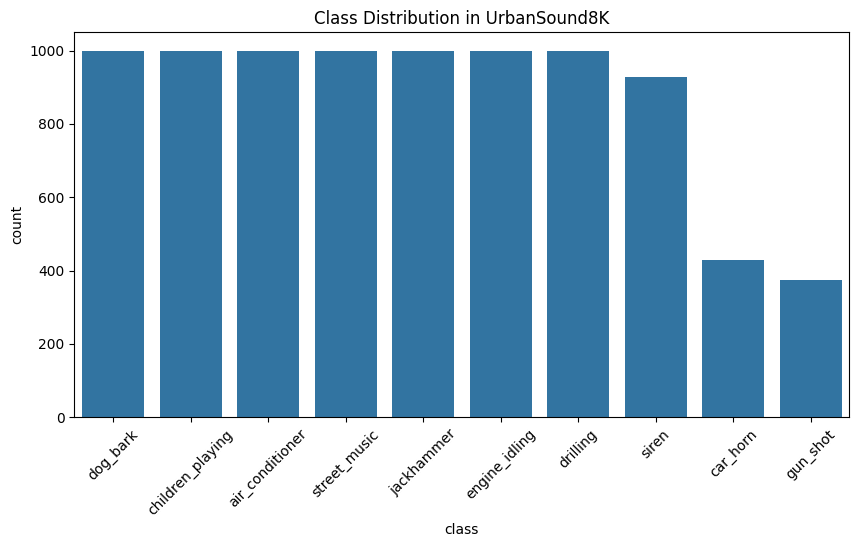

In [4]:
# Cell 4

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(data=df, x='class', order=df['class'].value_counts().index)

plt.title("Class Distribution in UrbanSound8K")
plt.xticks(rotation=45)
plt.show()

In [5]:
# Cell 5

audio_path = "/kaggle/input/datasets/rupakroy/urban-sound-8k/UrbanSound8K/UrbanSound8K/audio"

print("Audio path set successfully")

Audio path set successfully


In [6]:
import librosa
# Cell 6

row = df.iloc[0]

file_name = row["slice_file_name"]
fold = row["fold"]

file_path = audio_path + "/fold" + str(fold) + "/" + file_name

audio, sample_rate = librosa.load(file_path)

print("File Name:", file_name)
print("Class:", row["class"])
print("Sample Rate:", sample_rate)
print("Audio Shape:", audio.shape)

File Name: 100032-3-0-0.wav
Class: dog_bark
Sample Rate: 22050
Audio Shape: (7002,)


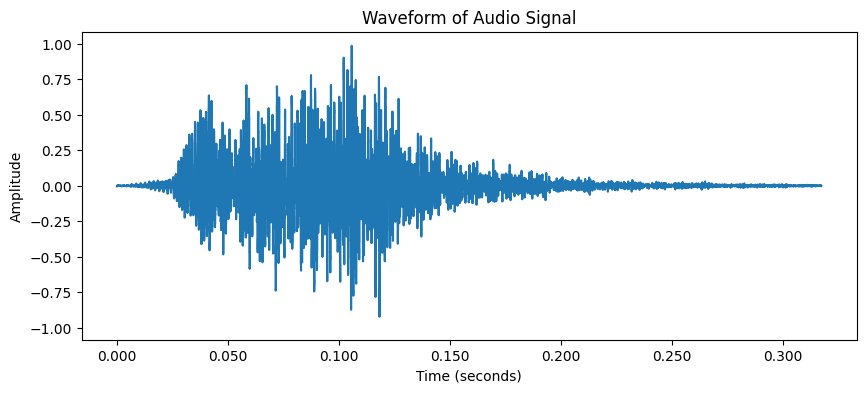

In [7]:
# Cell 7

import librosa.display

plt.figure(figsize=(10,4))
librosa.display.waveshow(audio, sr=sample_rate)

plt.title("Waveform of Audio Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

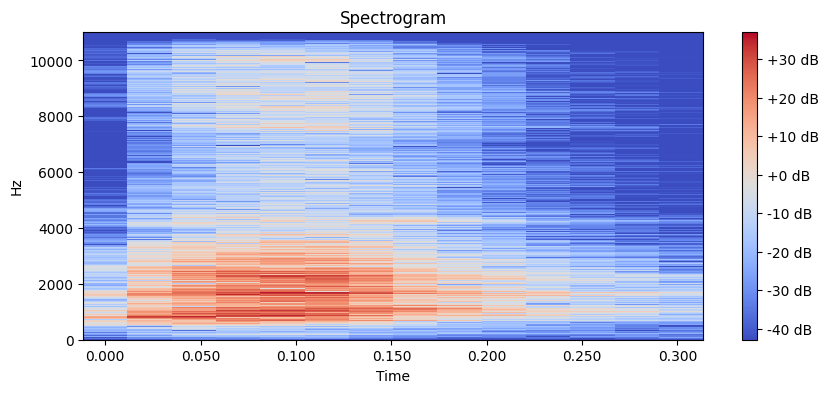

In [8]:
# Cell 8

spectrogram = librosa.stft(audio)
spectrogram_db = librosa.amplitude_to_db(abs(spectrogram))

plt.figure(figsize=(10,4))
librosa.display.specshow(spectrogram_db, sr=sample_rate, x_axis='time', y_axis='hz')

plt.title("Spectrogram")
plt.colorbar(format="%+2.0f dB")
plt.show()

MFCC Shape: (40, 14)


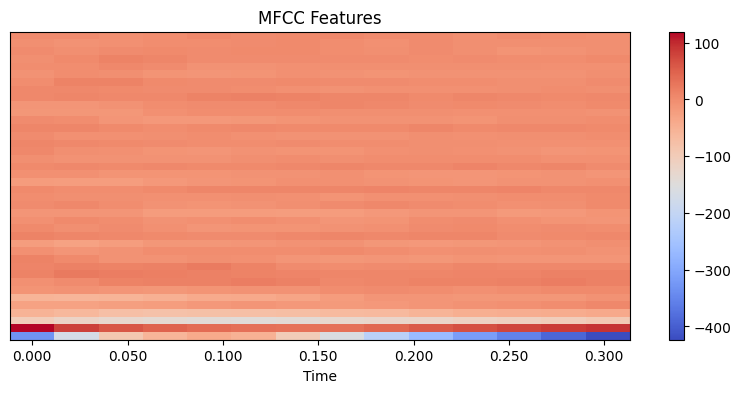

In [9]:
# Cell 9
#Extract MFCC Features
mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)

print("MFCC Shape:", mfccs.shape)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfccs, x_axis='time')
plt.colorbar()
plt.title("MFCC Features")
plt.show()

In [10]:
# Cell 10
#Create MFCC Feature Extraction Function
def extract_features(file_path):
    
    audio, sample_rate = librosa.load(file_path)
    
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    
    mfccs_scaled = np.mean(mfccs.T, axis=0)
    
    return mfccs_scaled

In [11]:
# Cell 11

features = []
labels = []

for index, row in df.iterrows():
    
    file_name = row["slice_file_name"]
    fold = row["fold"]
    
    file_path = audio_path + "/fold" + str(fold) + "/" + file_name
    
    data = extract_features(file_path)
    
    features.append(data)
    labels.append(row["class"])
    
print("Feature extraction completed")

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(


Feature extraction completed


In [12]:
# Cell 12

X = np.array(features)
y = np.array(labels)

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)

Feature shape: (8732, 40)
Labels shape: (8732,)


In [13]:
# Cell 13

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)
print("Encoded label example:", y_encoded[:10])

Classes: ['air_conditioner' 'car_horn' 'children_playing' 'dog_bark' 'drilling'
 'engine_idling' 'gun_shot' 'jackhammer' 'siren' 'street_music']
Encoded label example: [3 2 2 2 2 2 2 2 2 1]


In [14]:
# Cell 14

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (6985, 40)
Testing samples: (1747, 40)


In [15]:
# Cell 15

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [16]:
# Cell 16

from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8780767029192902


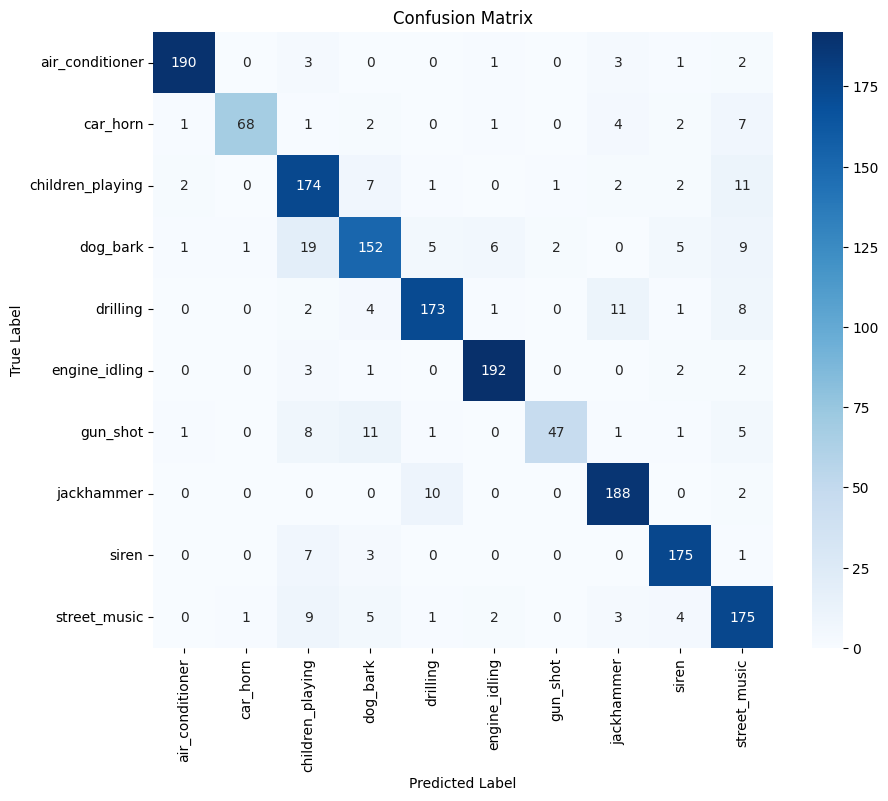

In [17]:
# Cell 17

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [18]:
# Cell 18

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
)

print(report)

                  precision    recall  f1-score   support

 air_conditioner       0.97      0.95      0.96       200
        car_horn       0.97      0.79      0.87        86
children_playing       0.77      0.87      0.82       200
        dog_bark       0.82      0.76      0.79       200
        drilling       0.91      0.86      0.88       200
   engine_idling       0.95      0.96      0.95       200
        gun_shot       0.94      0.63      0.75        75
      jackhammer       0.89      0.94      0.91       200
           siren       0.91      0.94      0.92       186
    street_music       0.79      0.88      0.83       200

        accuracy                           0.88      1747
       macro avg       0.89      0.86      0.87      1747
    weighted avg       0.88      0.88      0.88      1747



In [19]:
# Cell 19

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import BatchNormalization

print("TensorFlow Version:", tf.__version__)

2026-04-08 22:39:26.011721: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775687966.202285      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775687966.259786      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775687966.725749      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775687966.725811      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775687966.725814      24 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0


In [20]:
# Cell 20

def extract_mel_spectrogram(file_path):

    audio, sr = librosa.load(file_path, duration=4)

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=128
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    return mel_db

In [21]:
# Cell 21

X_mel = []
y_mel = []

for index, row in df.iterrows():

    file_name = row["slice_file_name"]
    fold = row["fold"]

    file_path = audio_path + "/fold" + str(fold) + "/" + file_name

    mel = extract_mel_spectrogram(file_path)

    X_mel.append(mel)
    y_mel.append(row["class"])

print("Mel Spectrogram extraction completed")

/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(


Mel Spectrogram extraction completed


In [22]:
# Cell 22

import cv2

X_resized = []

for mel in X_mel:
    
    mel_resized = cv2.resize(mel, (128, 128))
    
    X_resized.append(mel_resized)

X_resized = np.array(X_resized)

print("Spectrogram dataset shape:", X_resized.shape)

Spectrogram dataset shape: (8732, 128, 128)


In [23]:
# Cell 23

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_cnn = encoder.fit_transform(y_mel)

print("Classes:", encoder.classes_)

Classes: ['air_conditioner' 'car_horn' 'children_playing' 'dog_bark' 'drilling'
 'engine_idling' 'gun_shot' 'jackhammer' 'siren' 'street_music']


In [24]:
# Cell 24

from sklearn.model_selection import train_test_split

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_resized,
    y_cnn,
    test_size=0.2,
    random_state=42,
    stratify=y_cnn
)

print("Train shape:", X_train_cnn.shape)
print("Test shape:", X_test_cnn.shape)

Train shape: (6985, 128, 128)
Test shape: (1747, 128, 128)


In [25]:
# Cell 25

X_train_cnn = X_train_cnn[..., np.newaxis]
X_test_cnn = X_test_cnn[..., np.newaxis]

print("Train shape:", X_train_cnn.shape)
print("Test shape:", X_test_cnn.shape)

Train shape: (6985, 128, 128, 1)
Test shape: (1747, 128, 128, 1)


In [26]:
# Cell 26

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1775688157.698497      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775688157.704262      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,922 (24.87 MB)

 Trainable params: 6,518,474 (24.87 MB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
# Cell 27

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


In [28]:
# Cell 28

history = model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cnn)
)

Epoch 1/20


I0000 00:00:1775688162.742726      93 service.cc:152] XLA service 0x78b6fc014190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775688162.742782      93 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775688162.742788      93 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775688163.242995      93 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-08 22:42:45.011198: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 22:42:45.159534: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  7/219 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.2169 - loss: 11.4168

I0000 00:00:1775688168.072749      93 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


217/219 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4068 - loss: 4.3109

2026-04-08 22:42:53.399135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-08 22:42:53.543179: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - accuracy: 0.4079 - loss: 4.2844 - val_accuracy: 0.6348 - val_loss: 1.2172
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6199 - loss: 1.1315 - val_accuracy: 0.6251 - val_loss: 1.2925
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.7105 - loss: 0.8685 - val_accuracy: 0.6302 - val_loss: 1.7292
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7934 - loss: 0.6202 - val_accuracy: 0.7842 - val_loss: 0.7075
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8365 - loss: 0.4967 - val_accuracy: 0.7613 - val_loss: 1.0827
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8721 - loss: 0.3952 - val_accuracy: 0.2301 - val_loss: 10.9316
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8985 - loss: 0.3244 - val_accuracy: 0.8414 - val_loss: 0.5601
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.9148 - loss: 0.2635 - val_accuracy: 0.5

In [29]:
# Cell 29

test_loss, test_accuracy = model.evaluate(X_test_cnn, y_test_cnn)

print("CNN Test Accuracy:", test_accuracy)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8520 - loss: 0.9307
CNN Test Accuracy: 0.8683457374572754


In [30]:
# Cell 30

from tensorflow.keras.layers import Input, GlobalAveragePooling2D

model = Sequential()

model.add(Input(shape=(128,128,1)))

model.add(Conv2D(32,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(GlobalAveragePooling2D())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(10,activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [31]:
# Cell 31

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
# Cell 32

history = model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_cnn, y_test_cnn)
)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.3855 - loss: 1.7103 - val_accuracy: 0.2513 - val_loss: 3.1075
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.6292 - loss: 1.0617 - val_accuracy: 0.5009 - val_loss: 1.3736
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7119 - loss: 0.8349 - val_accuracy: 0.4740 - val_loss: 1.6662
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7717 - loss: 0.6742 - val_accuracy: 0.4808 - val_loss: 1.8757
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8155 - loss: 0.5670 - val_accuracy: 0.7178 - val_loss: 0.8377
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8293 - loss: 0.5297 - val_accuracy: 0.6365 - val_loss: 1.0988
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.8747 - loss: 0.4085 - val_accuracy: 0.6176 - val_loss: 1.2154
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.8803 - loss: 0.3843 - val_acc

In [33]:
# Cell 33

X_train_rgb = np.repeat(X_train_cnn, 3, axis=-1)
X_test_rgb = np.repeat(X_test_cnn, 3, axis=-1)

print("Train shape:", X_train_rgb.shape)
print("Test shape:", X_test_rgb.shape)

Train shape: (6985, 128, 128, 3)
Test shape: (1747, 128, 128, 3)


In [34]:
# Cell 34

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

In [35]:
# Cell 35

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(128,128,3)
)

for layer in base_model.layers:
    layer.trainable = False

print("ResNet base model loaded")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
ResNet base model loaded


In [36]:
# Cell 36

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)

predictions = Dense(10, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.summary()

Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [37]:
# Cell 37

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("ResNet model compiled")

ResNet model compiled


In [38]:
# Cell 38

history = model.fit(
    X_train_rgb,
    y_train_cnn,
    epochs=15,
    batch_size=32,
    validation_data=(X_test_rgb, y_test_cnn)
)

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 32s 95ms/step - accuracy: 0.5698 - loss: 1.3184 - val_accuracy: 0.8088 - val_loss: 0.5783
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.8076 - loss: 0.5633 - val_accuracy: 0.8426 - val_loss: 0.4871
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.8470 - loss: 0.4529 - val_accuracy: 0.8764 - val_loss: 0.3876
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.8851 - loss: 0.3376 - val_accuracy: 0.8861 - val_loss: 0.3528
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9121 - loss: 0.2678 - val_accuracy: 0.8884 - val_loss: 0.3369
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9021 - loss: 0.2719 - val_accuracy: 0.8832 - val_loss: 0.3432
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9275 - loss: 0.2123 - val_accuracy: 0.8987 - val_loss: 0.3121
Epoch 8/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9356 - loss: 0.1884 - val_ac

In [39]:
# Cell 39

loss, acc = model.evaluate(X_test_rgb, y_test_cnn)

print("ResNet Test Accuracy:", acc)

55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9270 - loss: 0.2593
ResNet Test Accuracy: 0.9164281487464905


55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step


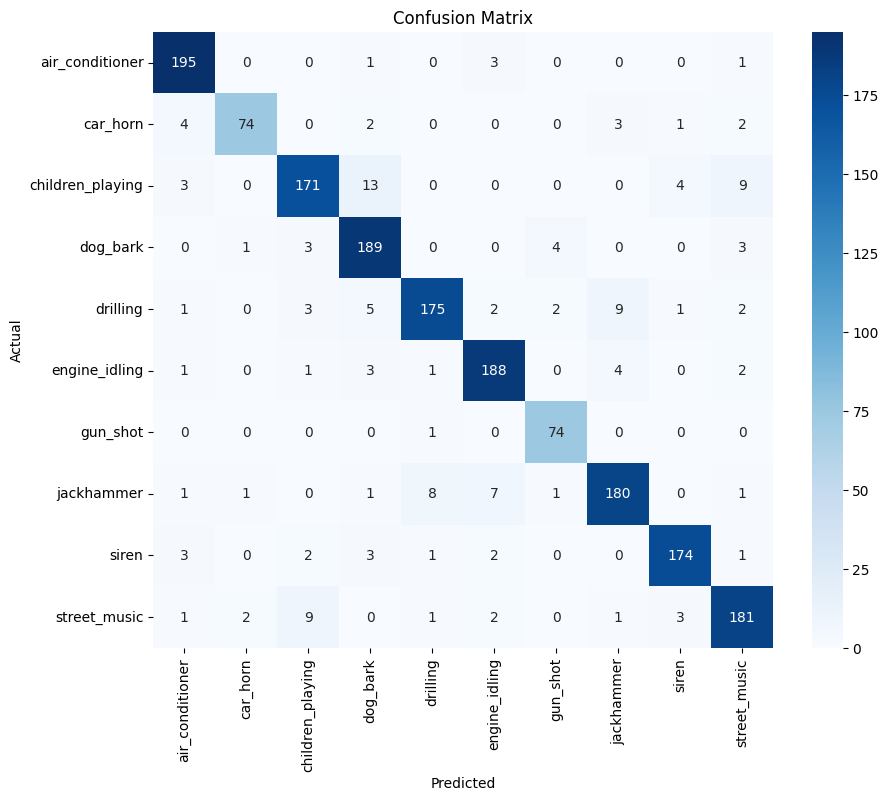

In [40]:
# Cell 42

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# define class names again
classes = sorted(df['class'].unique())

y_pred = model.predict(X_test_rgb)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test_cnn, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=classes,
            yticklabels=classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()